In [ ]:
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
urllib.request.urlretrieve(url, "spam.zip")

import zipfile
with zipfile.ZipFile("spam.zip", "r") as z:
    z.extractall(".")

print("Dataset downloaded and extracted!")

Dataset downloaded and extracted!


In [ ]:
import pandas as pd

df = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["label", "message"])

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nSpam vs Ham count:")
print(df["label"].value_counts())

Shape: (5572, 2)

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Spam vs Ham count:
label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert label to numbers: spam=1, ham=0
df["label"] = df["label"].map({"spam": 1, "ham": 0})

# Split into input (X) and output (y)
X = df["message"]
y = df["label"]

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text into numbers using TF-IDF
vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training samples:", X_train_tfidf.shape[0])
print("Testing samples:", X_test_tfidf.shape[0])
print("Data preparation complete!")

Training samples: 4457
Testing samples: 1115
Data preparation complete!


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Model 1: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

# Compare both models
models = {"Naive Bayes": nb_pred, "Logistic Regression": lr_pred}

for name, pred in models.items():
    print(f"\n{name}:")
    print(f"  Accuracy  : {accuracy_score(y_test, pred):.4f}")
    print(f"  Precision : {precision_score(y_test, pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_test, pred):.4f}")


Naive Bayes:
  Accuracy  : 0.9848
  Precision : 0.9925
  Recall    : 0.8926
  F1 Score  : 0.9399

Logistic Regression:
  Accuracy  : 0.9785
  Precision : 1.0000
  Recall    : 0.8389
  F1 Score  : 0.9124


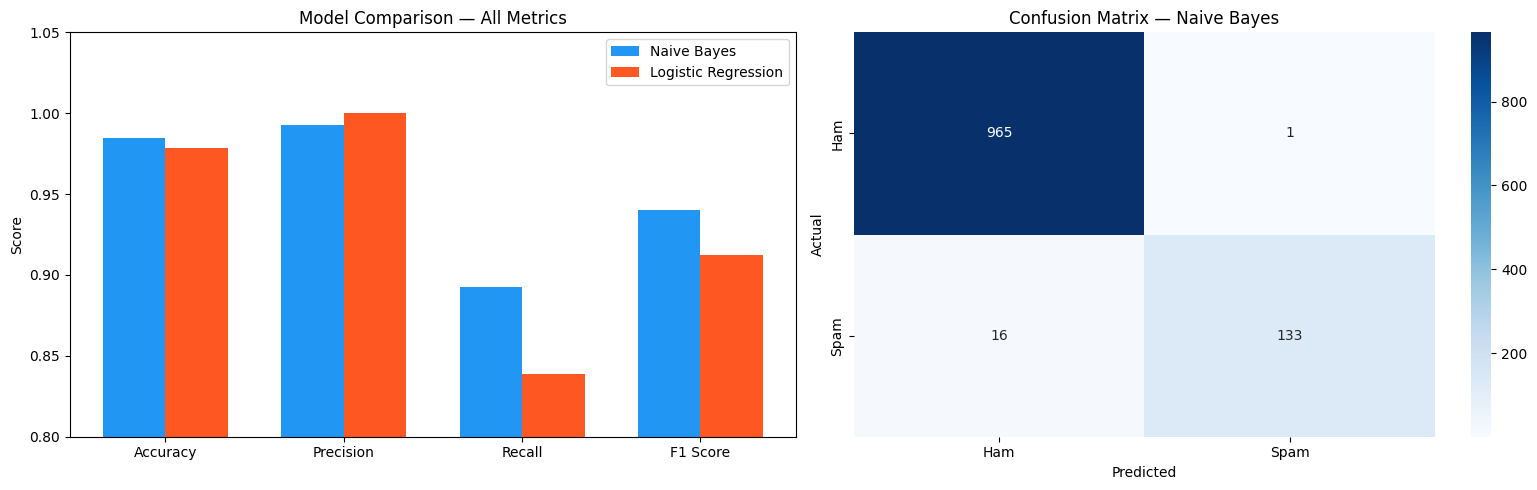

Charts saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Data for comparison chart
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
nb_scores = [0.9848, 0.9925, 0.8926, 0.9399]
lr_scores = [0.9785, 1.0000, 0.8389, 0.9124]

x = range(len(metrics))
width = 0.35

# Plot 1: Side by side comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar([i - width/2 for i in x], nb_scores, width, label="Naive Bayes", color="#2196F3")
axes[0].bar([i + width/2 for i in x], lr_scores, width, label="Logistic Regression", color="#FF5722")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.8, 1.05)
axes[0].set_title("Model Comparison — All Metrics")
axes[0].legend()
axes[0].set_ylabel("Score")

# Plot 2: Confusion matrix for Naive Bayes (winner)
cm = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"],
            ax=axes[1])
axes[1].set_title("Confusion Matrix — Naive Bayes")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("model_results.png", dpi=150)
plt.show()
print("Charts saved!")

In [1]:
print("=" * 60)
print("       SPAM DETECTION - MODEL COMPARISON REPORT")
print("=" * 60)

print("""
DATASET
-------
Source  : UCI ML Repository - SMS Spam Collection
Total   : 5,572 messages
Ham     : 4,825 (86.6%)
Spam    : 747 (13.4%)
Split   : 80% Training / 20% Testing

TEXT PREPROCESSING
------------------
Method  : TF-IDF Vectorization
Features: 3,000 most frequent words
Filter  : English stop words removed

MODEL RESULTS
-------------
                  Naive Bayes    Logistic Regression
Accuracy          98.48%         97.85%
Precision         99.25%         100.00%
Recall            89.26%         83.89%
F1 Score          93.99%         91.24%

CONFUSION MATRIX (Naive Bayes)
------------------------------
True Ham   (Correct) : 965
True Spam  (Correct) : 133
False Spam (Wrong)   : 1
Missed Spam (Wrong)  : 16

CONCLUSION
----------
Naive Bayes is the better model for spam detection.
Higher F1 Score (93.99%) and better Recall means it
catches more spam while maintaining strong precision.
Logistic Regression achieved perfect precision (100%)
but missed more spam messages overall.

Best Model : Naive Bayes
Key Metric : F1 Score
Use Case   : General purpose spam filtering
""")
print("=" * 60)
print("Task 1 Complete!")
print("=" * 60)

       SPAM DETECTION - MODEL COMPARISON REPORT

DATASET
-------
Source  : UCI ML Repository - SMS Spam Collection
Total   : 5,572 messages
Ham     : 4,825 (86.6%)
Spam    : 747 (13.4%)
Split   : 80% Training / 20% Testing

TEXT PREPROCESSING
------------------
Method  : TF-IDF Vectorization
Features: 3,000 most frequent words
Filter  : English stop words removed

MODEL RESULTS
-------------
                  Naive Bayes    Logistic Regression
Accuracy          98.48%         97.85%
Precision         99.25%         100.00%
Recall            89.26%         83.89%
F1 Score          93.99%         91.24%

CONFUSION MATRIX (Naive Bayes)
------------------------------
True Ham   (Correct) : 965
True Spam  (Correct) : 133
False Spam (Wrong)   : 1
Missed Spam (Wrong)  : 16

CONCLUSION
----------
Naive Bayes is the better model for spam detection.
Higher F1 Score (93.99%) and better Recall means it
catches more spam while maintaining strong precision.
Logistic Regression achieved perfect preci